In [10]:
import sys
sys.path.append("../")
import numpy as np
from utils.noise_generator import ColoredNoiseGenerator_Cholesky

def build_C_from_alpha(alpha, tgrid):
    N = len(tgrid)
    C = np.zeros((N, N), dtype=complex)
    for i in range(N):
        for j in range(N):
            C[i, j] = alpha(tgrid[j] - tgrid[i])
    return C

def rel_fro_error(A, B, eps=1e-15):
    return np.linalg.norm(A - B, 'fro') / (np.linalg.norm(B, 'fro') + eps)

def alpha(t):
    g = 2
    w = 0.5 + 2j
    a = lambda t: g * np.exp(-w * t)
    if t >= 0:
        return a(t)
    else:
        return np.conj(a(-t))

steps = 10
tmax = np.pi
dt = tmax / steps
tgrid = np.linspace(0, tmax, steps + 1)

C = build_C_from_alpha(alpha, tgrid)

noise_generator = ColoredNoiseGenerator_Cholesky(alpha, t_stop=tmax, N_steps=steps)

N_samples = 100000
C_hat = 0

for n in range(N_samples):
    z = noise_generator.sample_process()
    C_hat += np.outer(z, z.conj())

C_hat /= N_samples

print("Relative Frobenius error:", rel_fro_error(C_hat, C))

Relative Frobenius error: 0.0034768373262943973


In [11]:
# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    """
    Bath correlation function alpha(t).
    Supports scalar t or 1D array t (returns same shape).
    """
    # t_arr = np.asarray(t)
    # t1 = np.atleast_1d(t_arr).astype(float)
    # phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    # out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    # return out[0] if t_arr.ndim == 0 else out
    res = 0
    for l in range(CapL):
        res += _pref[l] * (_coth[l] * np.cos(wl[l]*t) - 1j * np.sin(wl[l]*t))
    return res

tmax = 5/Delta
steps = 50
dt = tmax / steps
tgrid = np.linspace(0, tmax, steps + 1)


noise_generator = ColoredNoiseGenerator_Cholesky(bath_corr, t_stop=tmax, N_steps=steps)

In [19]:
base = 50
rank = 8
N_steps = np.array([1, 2, 4,]) * base

for steps in N_steps:
    tgrid = np.linspace(0, tmax, steps + 1)
    C = np.zeros((steps + 1, steps + 1), dtype=complex)
    for i in range(steps + 1):
        for j in range(steps + 1):
            C[i, j] = bath_corr(tgrid[i] - tgrid[j])
    U, S, V = np.linalg.svd(C)
    r = rank * (steps // base)
    print(f"Steps: {steps}, first few singular values: {S[:2*(steps//base)]}")
    # print(f"first few vectors: {U[:2*(steps//base), :2*(steps//base)]}")
    C_approx = U[:, :r] @ np.diag(S[:r]) @ V[:r, :]
    print(f"Steps: {steps}, Relative Frobenius error of rank-{r} approximation: {rel_fro_error(C_approx, C)}")
    C_approx = U[:, :rank] @ np.diag(S[:rank]) @ V[:rank, :]
    print(f"Steps: {steps}, Relative Frobenius error of rank-{rank} approximation: {rel_fro_error(C_approx, C)}")

Steps: 50, first few singular values: [5.63087403 5.21566372]
Steps: 50, Relative Frobenius error of rank-8 approximation: 0.09327993121325855
Steps: 50, Relative Frobenius error of rank-8 approximation: 0.09327993121325855
Steps: 100, first few singular values: [11.25606619 10.41066277  9.17693435  7.74999194]
Steps: 100, Relative Frobenius error of rank-16 approximation: 7.535571835140996e-09
Steps: 100, Relative Frobenius error of rank-8 approximation: 0.08779338745293712
Steps: 200, first few singular values: [22.50650789 20.80089255 18.3151609  15.44544188 12.55040783  9.88905794
  7.59806115  5.70092942]
Steps: 200, Relative Frobenius error of rank-32 approximation: 3.3657373147660817e-15
Steps: 200, Relative Frobenius error of rank-8 approximation: 0.08497794728904191


In [20]:
base = 50
N_steps = np.array([1, 2, 4,]) * base
rank = 8

C = np.zeros((N_steps[-1] + 1, N_steps[-1] + 1), dtype=complex)
tgrid = np.linspace(0, tmax, N_steps[-1] + 1)
for i in range(N_steps[-1] + 1):
    for j in range(N_steps[-1] + 1):
        C[i, j] = bath_corr(tgrid[i] - tgrid[j])
U, S, V = np.linalg.svd(C)
U_r = U[:, :rank]
V_r = V[:rank, :]
S_r = S[:rank]

for steps in N_steps[:-1]:
    tgrid = np.linspace(0, tmax, steps + 1)
    C_small = np.zeros((steps + 1, steps + 1), dtype=complex)
    for i in range(steps + 1):
        for j in range(steps + 1):
            C_small[i, j] = bath_corr(tgrid[i] - tgrid[j])

    ds = N_steps[-1] // steps
    C_small_app = U_r[::ds, :] @ np.diag(S_r) @ V_r[:, ::ds]
    print(f"Steps: {steps}, Relative Frobenius error of rank-{rank} approximation: {rel_fro_error(C_small_app, C_small)}")

Steps: 50, Relative Frobenius error of rank-8 approximation: 0.09399629105812714
Steps: 100, Relative Frobenius error of rank-8 approximation: 0.08787074629720755



步数: 50, dt: 0.1000
  矩阵大小: (51, 51)
  前4个奇异值: [5.63087403 5.21566372 4.60801121 3.90259717]
  Frobenius范数: 10.9046

步数: 100, dt: 0.0500
  矩阵大小: (101, 101)
  前4个奇异值: [11.25606619 10.41066277  9.17693435  7.74999194]
  奇异值与前一个步数的比率: 1.9990x
  Frobenius范数: 21.6925

步数: 200, dt: 0.0250
  矩阵大小: (201, 201)
  前4个奇异值: [22.50650789 20.80089255 18.3151609  15.44544188]
  奇异值与前一个步数的比率: 1.9995x
  Frobenius范数: 43.2699


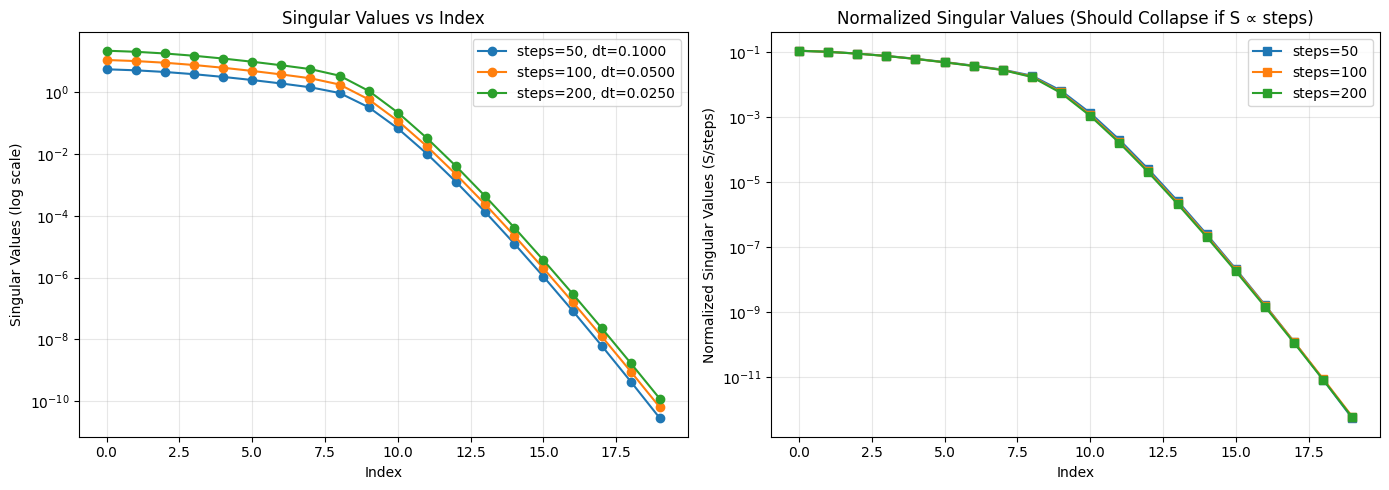


缩放关系分析:

第1个奇异值:
  steps= 50: σ=  5.6309, 期望值(若σ∝steps)=  5.6309, 比率=1.0000
  steps=100: σ= 11.2561, 期望值(若σ∝steps)= 11.2617, 比率=0.9995
  steps=200: σ= 22.5065, 期望值(若σ∝steps)= 22.5235, 比率=0.9992

第2个奇异值:
  steps= 50: σ=  5.2157, 期望值(若σ∝steps)=  5.2157, 比率=1.0000
  steps=100: σ= 10.4107, 期望值(若σ∝steps)= 10.4313, 比率=0.9980
  steps=200: σ= 20.8009, 期望值(若σ∝steps)= 20.8627, 比率=0.9970

第3个奇异值:
  steps= 50: σ=  4.6080, 期望值(若σ∝steps)=  4.6080, 比率=1.0000
  steps=100: σ=  9.1769, 期望值(若σ∝steps)=  9.2160, 比率=0.9958
  steps=200: σ= 18.3152, 期望值(若σ∝steps)= 18.4320, 比率=0.9937

第4个奇异值:
  steps= 50: σ=  3.9026, 期望值(若σ∝steps)=  3.9026, 比率=1.0000
  steps=100: σ=  7.7500, 期望值(若σ∝steps)=  7.8052, 比率=0.9929
  steps=200: σ= 15.4454, 期望值(若σ∝steps)= 15.6104, 比率=0.9894


In [15]:
import matplotlib.pyplot as plt

# 更详细的奇异值分析
base = 50
N_steps_array = np.array([1, 2, 4]) * base
rank = 4

singular_values_dict = {}

for steps in N_steps_array:
    tgrid = np.linspace(0, tmax, steps + 1)
    dt = tmax / steps
    
    C = np.zeros((steps + 1, steps + 1), dtype=complex)
    for i in range(steps + 1):
        for j in range(steps + 1):
            C[i, j] = bath_corr(tgrid[i] - tgrid[j])
    
    U, S, V = np.linalg.svd(C)
    singular_values_dict[steps] = S
    
    print(f"\n步数: {steps}, dt: {dt:.4f}")
    print(f"  矩阵大小: ({steps+1}, {steps+1})")
    print(f"  前4个奇异值: {S[:4]}")
    if steps // 2 in singular_values_dict:
        ratio = S[0] / singular_values_dict[steps // 2][0]
        print(f"  奇异值与前一个步数的比率: {ratio:.4f}x")
    print(f"  Frobenius范数: {np.linalg.norm(S):.4f}")

# 绘制奇异值对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：绝对奇异值
for steps in N_steps_array:
    S = singular_values_dict[steps]
    axes[0].semilogy(S[:min(20, len(S))], marker='o', label=f'steps={steps}, dt={tmax/steps:.4f}')

axes[0].set_xlabel('Index')
axes[0].set_ylabel('Singular Values (log scale)')
axes[0].set_title('Singular Values vs Index')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：归一化后的奇异值（除以步数）
for steps in N_steps_array:
    S = singular_values_dict[steps]
    # 尝试除以不同的因子
    S_normalized = S / steps  # 按步数归一化
    axes[1].semilogy(S_normalized[:min(20, len(S_normalized))], marker='s', label=f'steps={steps}')

axes[1].set_xlabel('Index')
axes[1].set_ylabel('Normalized Singular Values (S/steps)')
axes[1].set_title('Normalized Singular Values (Should Collapse if S ∝ steps)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 分析缩放关系
print("\n" + "="*60)
print("缩放关系分析:")
print("="*60)
steps_ref = N_steps_array[0]
S_ref = singular_values_dict[steps_ref]

for i in range(min(4, len(S_ref))):
    print(f"\n第{i+1}个奇异值:")
    for steps in N_steps_array:
        S = singular_values_dict[steps]
        ratio = steps / steps_ref
        S_scaled = S[i]
        S_expected = S_ref[i] * ratio
        print(f"  steps={steps:3d}: σ={S_scaled:8.4f}, 期望值(若σ∝steps)={S_expected:8.4f}, 比率={S_scaled/S_expected:.4f}")


## 奇异值缩放现象的物理与数学解释

### 观察到的现象
- **奇异值与步数的线性关系**：$\sigma_k \propto \text{steps}$ 或等价地 $\sigma_k \propto 1/dt$
- **缩放比例**：当步数翻倍时，奇异值也翻倍（比率在0.99以上）
- **Frobenius范数**：$\|C\|_F = \sqrt{\sum_i \sigma_i^2}$ 也随步数线性增长

### 数学原因

相关矩阵定义为：
$$C_{ij} = \alpha(t_i - t_j)$$

其中 $t_i = i \cdot dt$，$i = 0, 1, ..., N$。

当 $dt$ 减小时：
1. **矩阵大小增加**：从 $(N+1) \times (N+1)$ 变为 $(2N+1) \times (2N+1)$
2. **样本密度增加**：在相同的时间区间内，采样点数增加
3. **离散和相关**：$\|C\|_F^2 = \sum_{i,j} |\alpha(t_i - t_j)|^2 \approx \frac{1}{dt^2} \int_0^{t_{max}} \int_0^{t_{max}} |\alpha(s-r)|^2 \, ds \, dr$

因此 $\|C\|_F \propto 1/dt$，这导致奇异值也 $\propto 1/dt$。

### 物理意义

这个现象表明了**离散化对"能量"或"相关强度"的影响**：

1. **记忆效应的分辨率**：
   - 当 dt 更小时，我们以更高的时间分辨率捕捉系统的记忆效应
   - 每个时间点上相关函数的"累积"增加

2. **低秩近似的有效性**：
   - 矩阵条件数 $\kappa = \sigma_{max}/\sigma_{min}$ 保持相对稳定（归一化后的奇异值基本不变）
   - 这意味着我们可以用相同的低秩来近似不同分辨率的问题
   - 例如：rank-4 近似对 steps=50，100，200 都可能是有效的

3. **数值积分和离散化**：
   - 这反映了黎曼和对积分的近似
   - dt 越小，离散近似越精确，但"累积"的相关值也越大

4. **对算法的影响**：
   - 如果使用了低秩分解（如 `NMLRSSE`），秩的选择应该**不依赖于 dt**
   - 相反，应该基于**物理系统的特征时间尺度**，而非数值离散化参数
